# IMPORTS

## System

In [13]:
import sys
import os
from pathlib import Path
import pandas as pd

# Remonte de deux niveaux (si ton notebook est dans /notebooks/exploration.ipynb)
# pour atteindre la racine du projet
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [14]:
from config.config import *

from PIL import Image

## Données

In [15]:
images_non_labelisées_dir = BASE_DIR / "mri_dataset_brain_cancer_oc" / "sans_label"

In [16]:
metadata_list = []
image:Path

for image in images_non_labelisées_dir.glob('*') :
    img = Image.open(image)

    metadata = {
        'name' : image.name,
        'format' : img.format,
        'width' : img.width,
        'height' : img.height,
        'mode' : img.mode,
        'file_size' : os.path.getsize(image),
    }

    metadata_list.append(metadata)

df = pd.DataFrame(metadata_list)

## Visualisation

In [17]:
df.head()

,name,format,width,height,mode,file_size
0,001b158a-7af8-451e-bf31-3a9116265f3a.jpg,JPEG,512,512,RGB,30809
1,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,JPEG,512,512,RGB,15204
2,00455a62-f79f-4072-9a23-4951e759acdc.jpg,JPEG,512,512,RGB,19564
3,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,JPEG,512,512,RGB,23711
4,005d9a37-8894-4eb5-8367-1015d4a43638.jpg,JPEG,512,512,RGB,21771


In [18]:
df.describe(include='all')

,name,format,width,height,mode,file_size
count,1406,1406,1406.0,1406.0,1406,1406.000000
unique,1406,1,NaN,NaN,1,NaN
top,001b158a-7af8-451e-bf31-3a9116265f3a.jpg,JPEG,NaN,NaN,RGB,NaN
freq,1,1406,NaN,NaN,1406,NaN
mean,NaN,NaN,512.0,512.0,NaN,24629.298720
std,NaN,NaN,0.0,0.0,NaN,5975.265256
min,NaN,NaN,512.0,512.0,NaN,13373.000000
25%,NaN,NaN,512.0,512.0,NaN,21079.250000
50%,NaN,NaN,512.0,512.0,NaN,23764.000000
75%,NaN,NaN,512.0,512.0,NaN,27286.500000


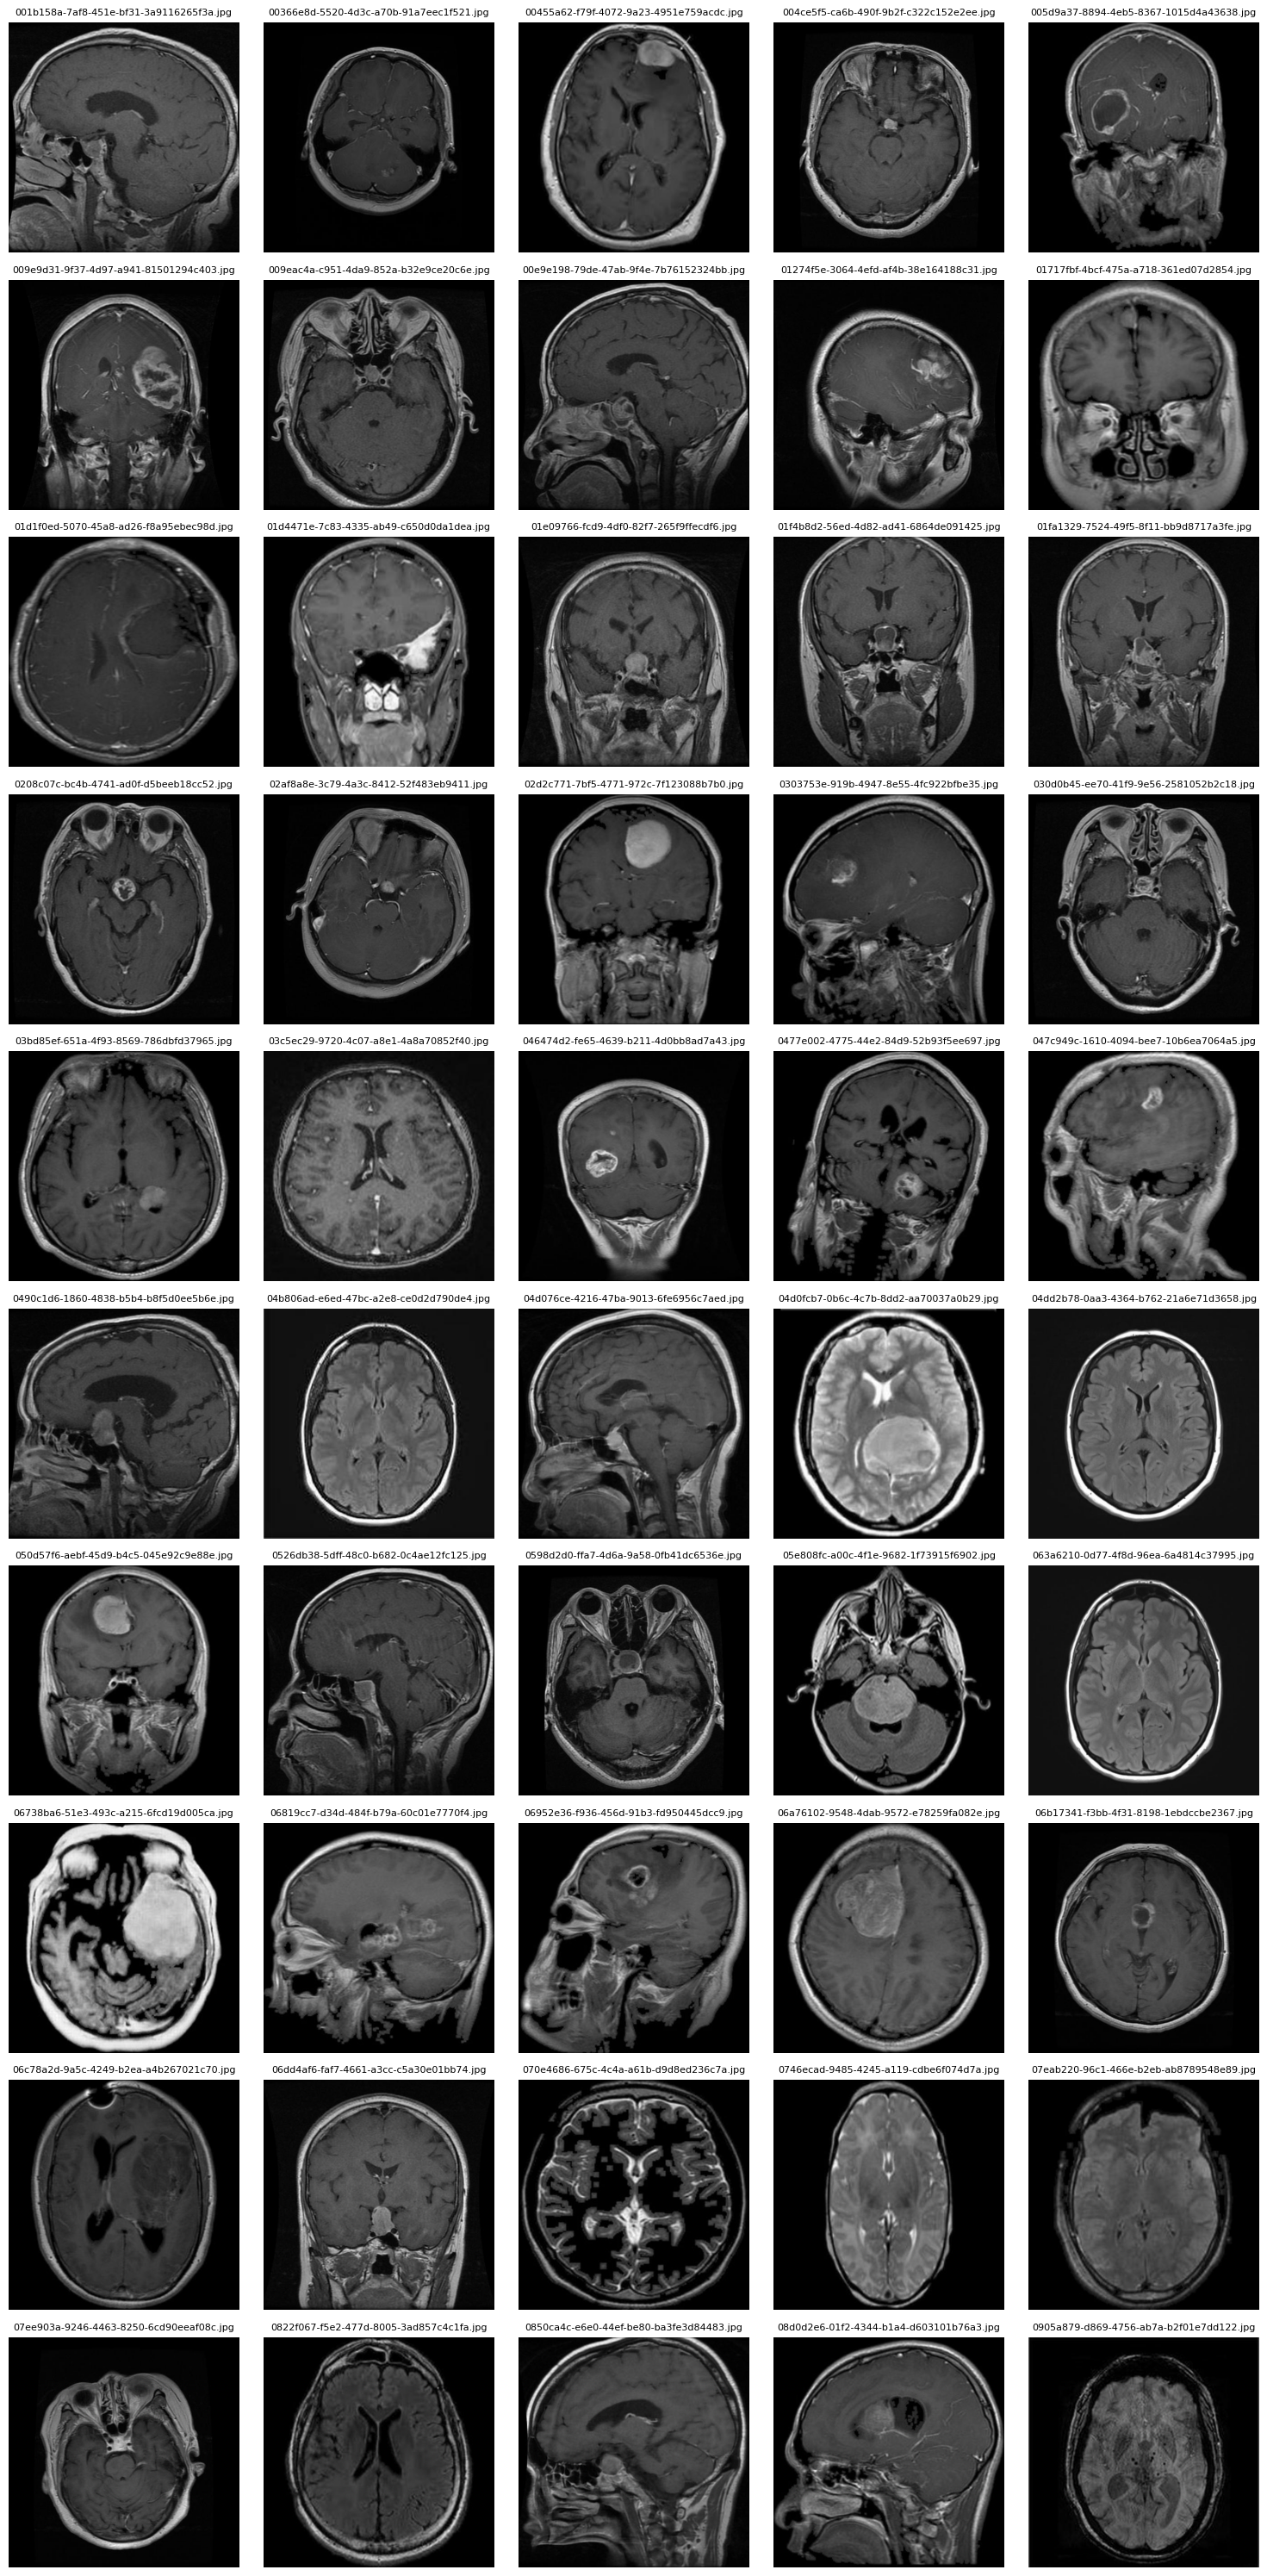

In [20]:
import matplotlib.pyplot as plt

# Récupérer les 10 premières images
images = list(images_non_labelisées_dir.glob('*'))[:50]

# Créer une grille 2x5
fig, axes = plt.subplots(10, 5, figsize=(15, 30))
axes = axes.flatten()

for idx, img_path in enumerate(images):
    img = Image.open(img_path)
    axes[idx].imshow(img)  # Sans cmap='gray' pour afficher en couleur
    axes[idx].set_title(img_path.name, fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Observations :
- Nous avons 1406 images non labelisées au format JPEG
- Images carrées de 512px
- Toutes au format jpeg
- Taille : mean = 24.6 Ko ; min = 13.3 Ko ; max = 75.5 Ko
- Toutes en RGB
- Les images sont prises sous différentes orientations : Haut, coté, face